In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/credit_risk_analytics.csv")

df.head()

,customer_id,credit_limit,sex,education,marriage,age,age_band,bill_sep,bill_aug,bill_jul,...,delinquency_severity,zero_payment_months_6m,made_recent_payment,delinquency_trajectory,behavioral_risk_score,risk_segment,exposure_band,collection_priority,default_next_month,recent_delinquency_status
0,1,20000,Female,University,Married,24,21-29,3913,3102,689,...,Moderate,5,0,Deteriorating,8,High,Low,Priority,1,2 Months Delinquent
1,2,120000,Female,University,Single,26,21-29,2682,1725,2682,...,Moderate,2,0,Stable,5,Medium,Low,Monitor,1,Current
2,3,90000,Female,University,Single,34,30-39,29239,14027,13559,...,Current,0,1,Stable,0,Low,Low,Routine,0,Current
3,4,50000,Female,University,Married,37,30-39,46990,48233,49291,...,Current,0,1,Stable,1,Low,Low,Routine,0,Current
4,5,50000,Male,University,Married,57,50-59,8617,5670,35835,...,Current,0,1,Stable,0,Low,Low,Routine,0,Current


In [3]:
print("Dataset Shape:", df.shape)

print("\nData Types")
display(df.dtypes)

print("\nFirst Five Rows")
display(df.head())

Dataset Shape: (30000, 37)

Data Types


customer_id                    int64
credit_limit                   int64
sex                           object
education                     object
marriage                      object
age                            int64
age_band                      object
bill_sep                       int64
bill_aug                       int64
bill_jul                       int64
bill_jun                       int64
bill_may                       int64
bill_apr                       int64
payment_sep                    int64
payment_aug                    int64
payment_jul                    int64
payment_jun                    int64
payment_may                    int64
payment_apr                    int64
current_exposure               int64
latest_utilization           float64
utilization_band              object
avg_bill_6m                  float64
avg_payment_6m               float64
months_delinquent_6m           int64
max_delinquency_6m             int64
recent_delinquency             int64
d


First Five Rows


,customer_id,credit_limit,sex,education,marriage,age,age_band,bill_sep,bill_aug,bill_jul,...,delinquency_severity,zero_payment_months_6m,made_recent_payment,delinquency_trajectory,behavioral_risk_score,risk_segment,exposure_band,collection_priority,default_next_month,recent_delinquency_status
0,1,20000,Female,University,Married,24,21-29,3913,3102,689,...,Moderate,5,0,Deteriorating,8,High,Low,Priority,1,2 Months Delinquent
1,2,120000,Female,University,Single,26,21-29,2682,1725,2682,...,Moderate,2,0,Stable,5,Medium,Low,Monitor,1,Current
2,3,90000,Female,University,Single,34,30-39,29239,14027,13559,...,Current,0,1,Stable,0,Low,Low,Routine,0,Current
3,4,50000,Female,University,Married,37,30-39,46990,48233,49291,...,Current,0,1,Stable,1,Low,Low,Routine,0,Current
4,5,50000,Male,University,Married,57,50-59,8617,5670,35835,...,Current,0,1,Stable,0,Low,Low,Routine,0,Current


In [5]:
missing = df.isnull().sum()


missing

customer_id                  0
credit_limit                 0
sex                          0
education                    0
marriage                     0
age                          0
age_band                     0
bill_sep                     0
bill_aug                     0
bill_jul                     0
bill_jun                     0
bill_may                     0
bill_apr                     0
payment_sep                  0
payment_aug                  0
payment_jul                  0
payment_jun                  0
payment_may                  0
payment_apr                  0
current_exposure             0
latest_utilization           0
utilization_band             0
avg_bill_6m                  0
avg_payment_6m               0
months_delinquent_6m         0
max_delinquency_6m           0
recent_delinquency           0
delinquency_severity         0
zero_payment_months_6m       0
made_recent_payment          0
delinquency_trajectory       0
behavioral_risk_score        0
risk_seg

In [6]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,30000.0,15000.500000,8660.398374,1.000000,7500.750000,15000.500000,22500.250000,3.000000e+04
credit_limit,30000.0,167484.322667,129747.661567,10000.000000,50000.000000,140000.000000,240000.000000,1.000000e+06
age,30000.0,35.485500,9.217904,21.000000,28.000000,34.000000,41.000000,7.900000e+01
bill_sep,30000.0,51223.330900,73635.860576,-165580.000000,3558.750000,22381.500000,67091.000000,9.645110e+05
bill_aug,30000.0,49179.075167,71173.768783,-69777.000000,2984.750000,21200.000000,64006.250000,9.839310e+05
bill_jul,30000.0,47013.154800,69349.387427,-157264.000000,2666.250000,20088.500000,60164.750000,1.664089e+06
bill_jun,30000.0,43262.948967,64332.856134,-170000.000000,2326.750000,19052.000000,54506.000000,8.915860e+05
bill_may,30000.0,40311.400967,60797.155770,-81334.000000,1763.000000,18104.500000,50190.500000,9.271710e+05
bill_apr,30000.0,38871.760400,59554.107537,-339603.000000,1256.000000,17071.000000,49198.250000,9.616640e+05
payment_sep,30000.0,5663.580500,16563.280354,0.000000,1000.000000,2100.000000,5006.000000,8.735520e+05


In [8]:
target_counts = df["default_next_month"].value_counts()

target_percent = df["default_next_month"].value_counts(normalize=True) * 100

print(target_counts)

print(target_percent)

default_next_month
0    23364
1     6636
Name: count, dtype: int64
default_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64


C:\Users\Sourya S\AppData\Local\Temp\ipykernel_32524\3309753306.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


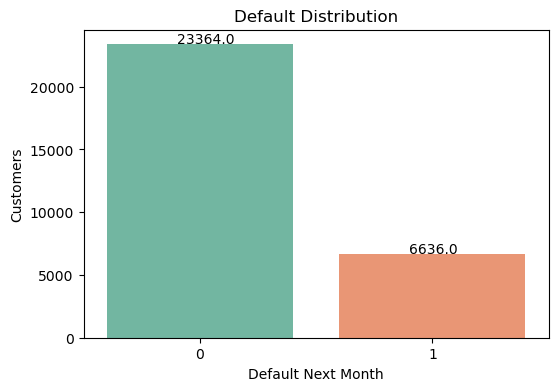

In [9]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="default_next_month",
    palette="Set2"
)

plt.title("Default Distribution")
plt.xlabel("Default Next Month")
plt.ylabel("Customers")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height()}",
        (p.get_x()+0.3,p.get_height()+50)
    )

plt.show()

In [10]:
numerical_features = [

"age",

"credit_limit",

"current_exposure",

"latest_utilization",

"avg_bill_6m",

"avg_payment_6m",

"behavioral_risk_score"

]

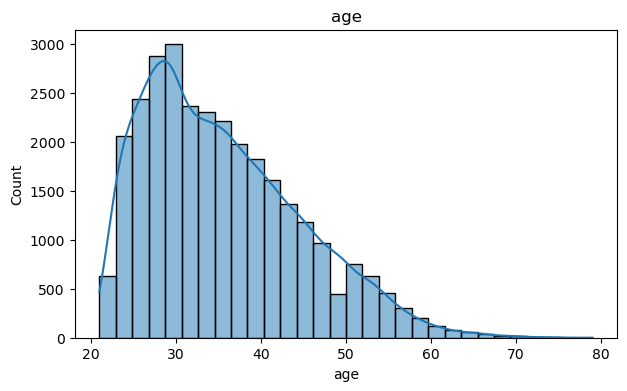

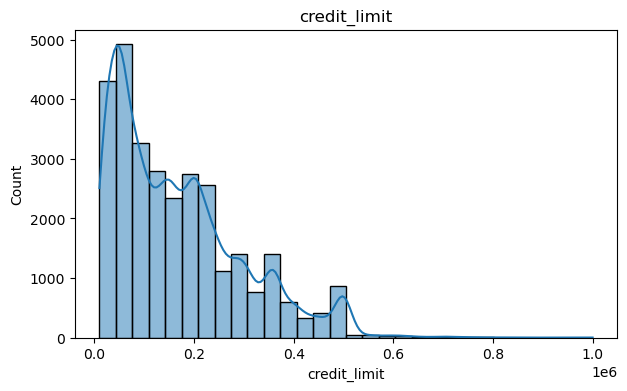

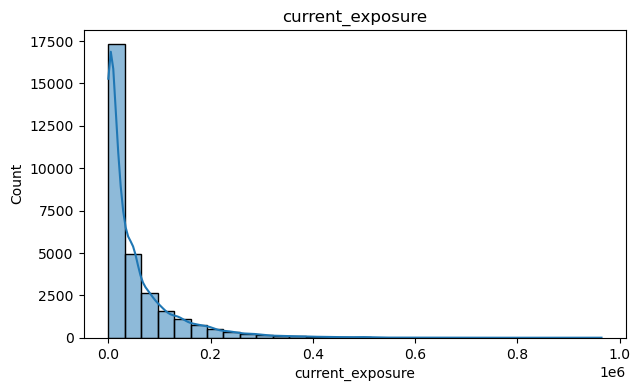

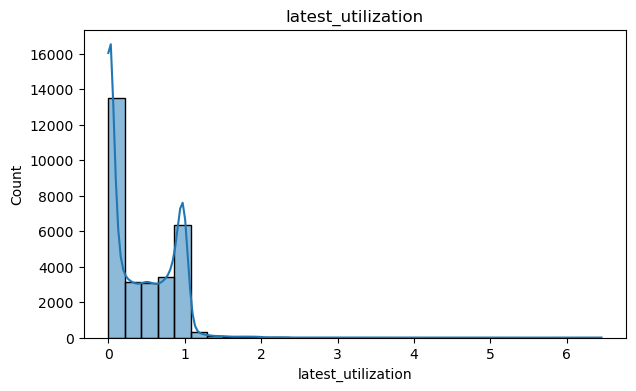

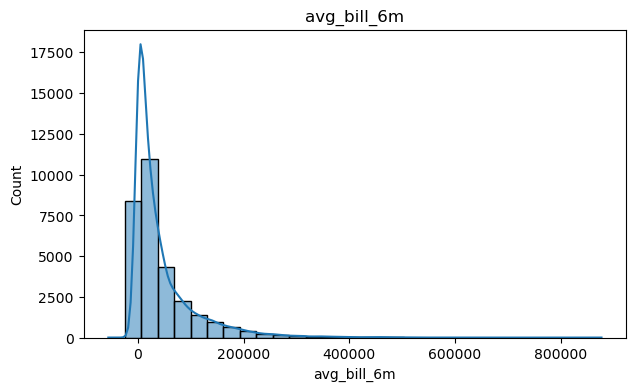

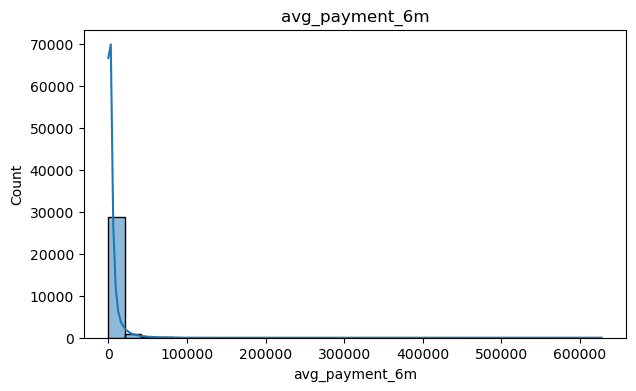

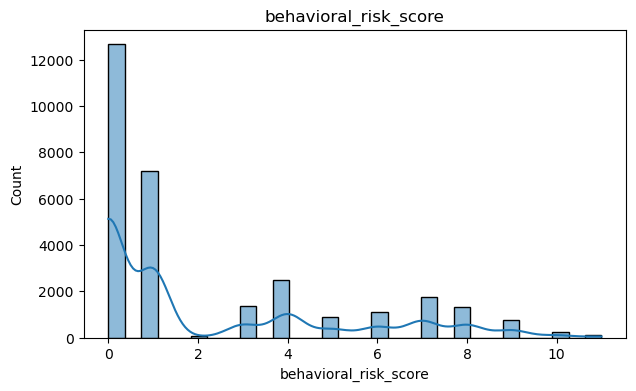

In [11]:
for col in numerical_features:

    plt.figure(figsize=(7,4))

    sns.histplot(df[col], bins=30, kde=True)

    plt.title(col)

    plt.show()

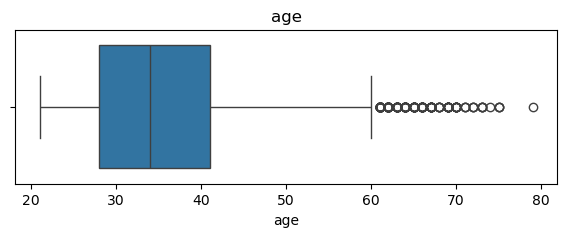

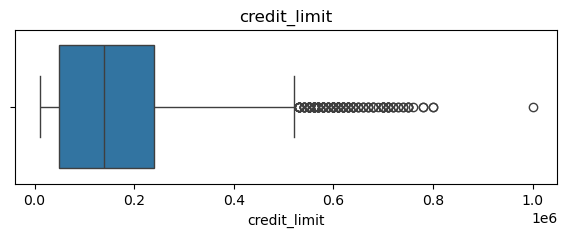

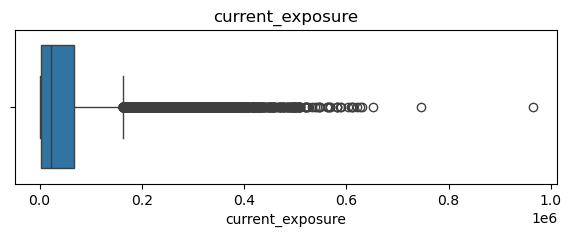

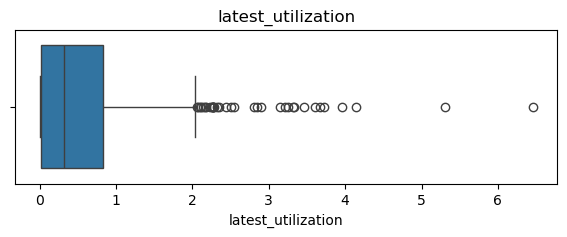

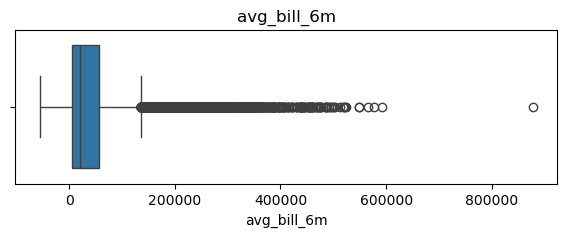

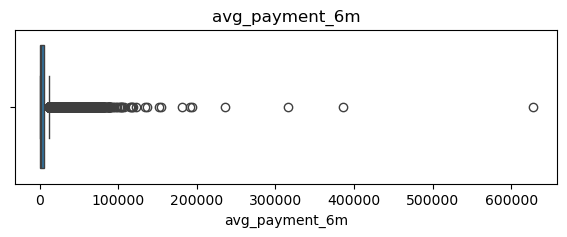

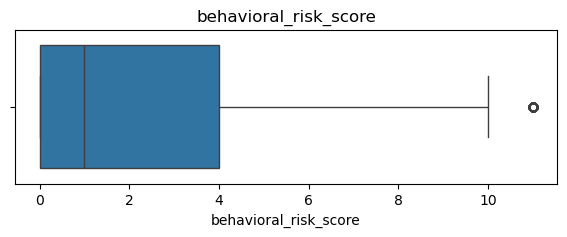

In [12]:
for col in numerical_features:

    plt.figure(figsize=(7,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

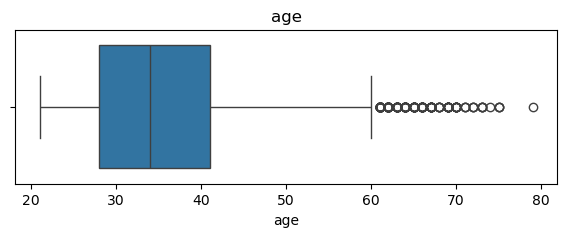

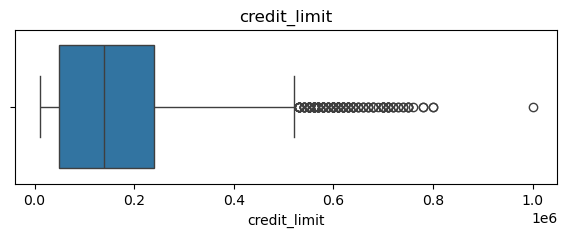

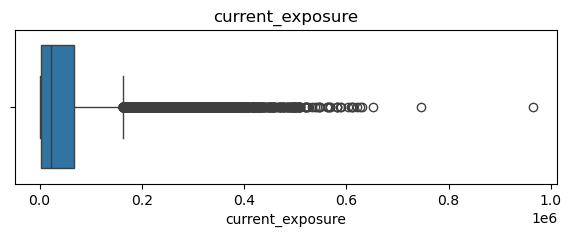

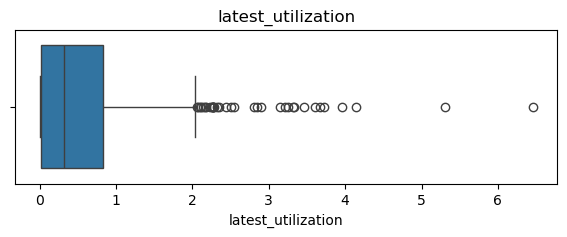

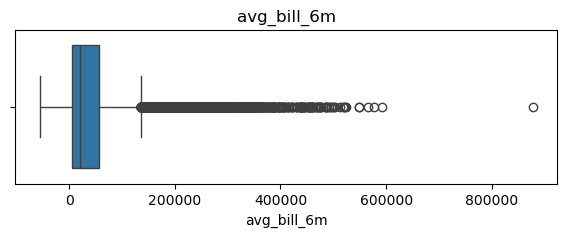

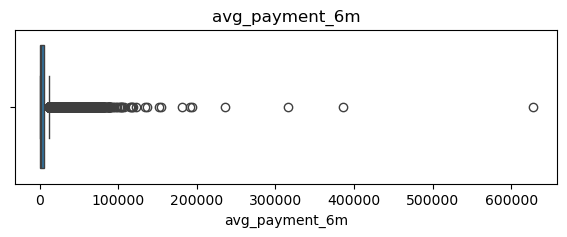

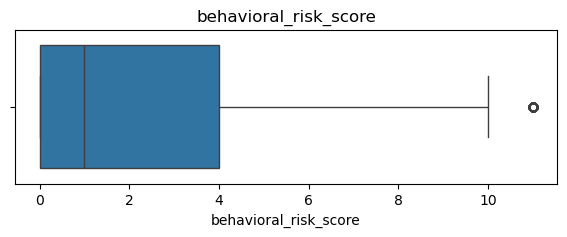

In [13]:
for col in numerical_features:

    plt.figure(figsize=(7,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [14]:
risk_default = (
    df.groupby("risk_segment")["default_next_month"]
      .mean()
      .sort_values()
      .reset_index()
)

risk_default

,risk_segment,default_next_month
0,Low,0.122034
1,Medium,0.277381
2,High,0.579772


C:\Users\Sourya S\AppData\Local\Temp\ipykernel_32524\1065224771.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


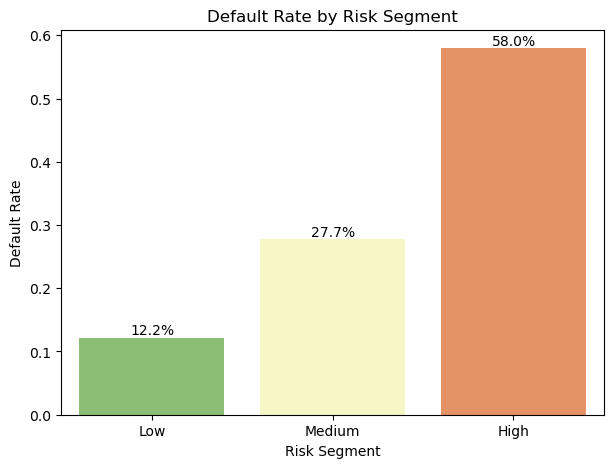

In [15]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=risk_default,
    x="risk_segment",
    y="default_next_month",
    order=["Low","Medium","High"],
    palette="RdYlGn_r"
)

plt.title("Default Rate by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Default Rate")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height()*100:.1f}%",
        (p.get_x()+0.28,p.get_height()+0.005)
    )

plt.show()

In [16]:
priority_order = [
    "Routine",
    "Monitor",
    "Priority",
    "High Priority",
    "Critical"
]

collection_default = (
    df.groupby("collection_priority")["default_next_month"]
      .mean()
      .reindex(priority_order)
      .reset_index()
)

C:\Users\Sourya S\AppData\Local\Temp\ipykernel_32524\2795755107.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


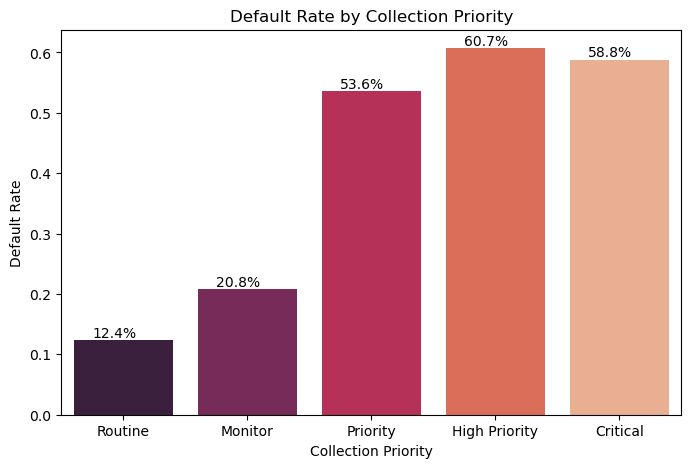

In [17]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=collection_default,
    x="collection_priority",
    y="default_next_month",
    palette="rocket"
)

plt.title("Default Rate by Collection Priority")
plt.xlabel("Collection Priority")
plt.ylabel("Default Rate")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height()*100:.1f}%",
        (p.get_x()+0.15,p.get_height()+0.005)
    )

plt.show()

In [18]:
severity_order = [
    "Current",
    "Moderate",
    "Severe"
]

severity_default = (
    df.groupby("delinquency_severity")["default_next_month"]
      .mean()
      .reindex(severity_order)
      .reset_index()
)

C:\Users\Sourya S\AppData\Local\Temp\ipykernel_32524\3765979931.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


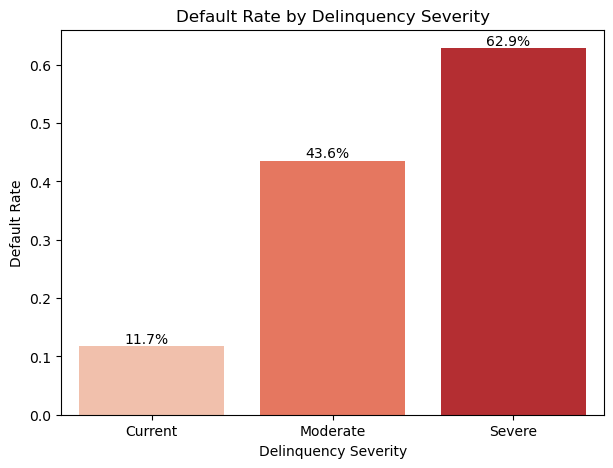

In [19]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=severity_default,
    x="delinquency_severity",
    y="default_next_month",
    palette="Reds"
)

plt.title("Default Rate by Delinquency Severity")
plt.xlabel("Delinquency Severity")
plt.ylabel("Default Rate")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height()*100:.1f}%",
        (p.get_x()+0.25,p.get_height()+0.005)
    )

plt.show()

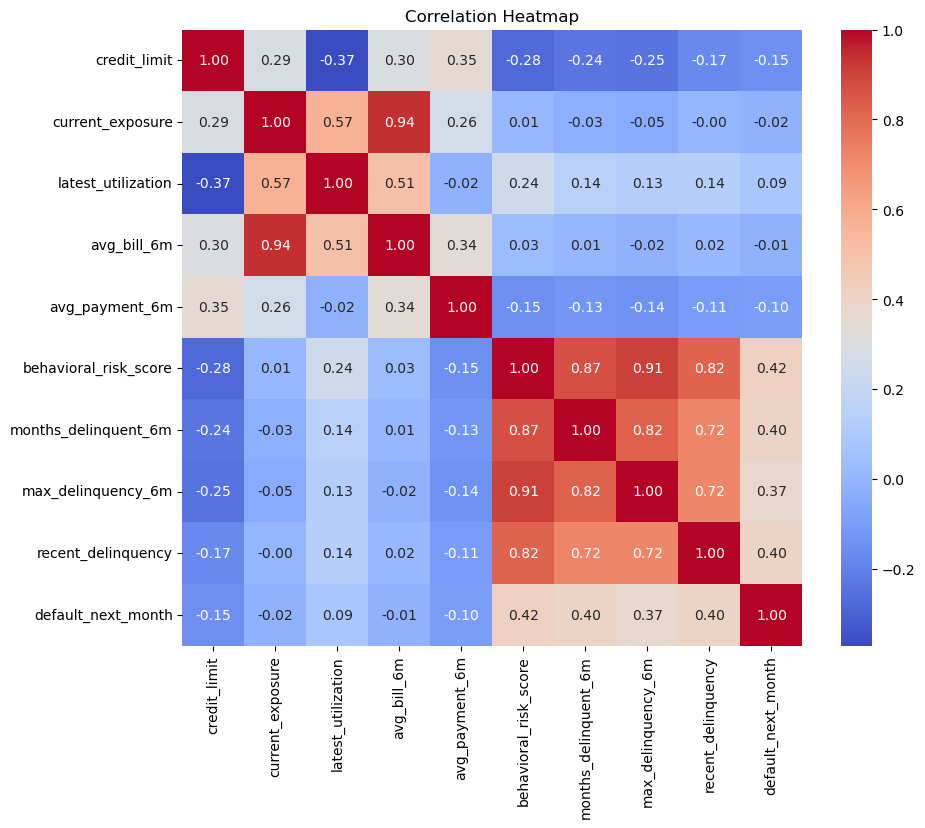

In [20]:
corr_features = [
    "credit_limit",
    "current_exposure",
    "latest_utilization",
    "avg_bill_6m",
    "avg_payment_6m",
    "behavioral_risk_score",
    "months_delinquent_6m",
    "max_delinquency_6m",
    "recent_delinquency",
    "default_next_month"
]

corr = df[corr_features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [21]:
corr_target = (
    corr["default_next_month"]
    .sort_values(ascending=False)
)

corr_target

default_next_month       1.000000
behavioral_risk_score    0.421757
months_delinquent_6m     0.398394
recent_delinquency       0.396019
max_delinquency_6m       0.370388
latest_utilization       0.086092
avg_bill_6m             -0.012691
current_exposure        -0.019765
avg_payment_6m          -0.102354
credit_limit            -0.153520
Name: default_next_month, dtype: float64

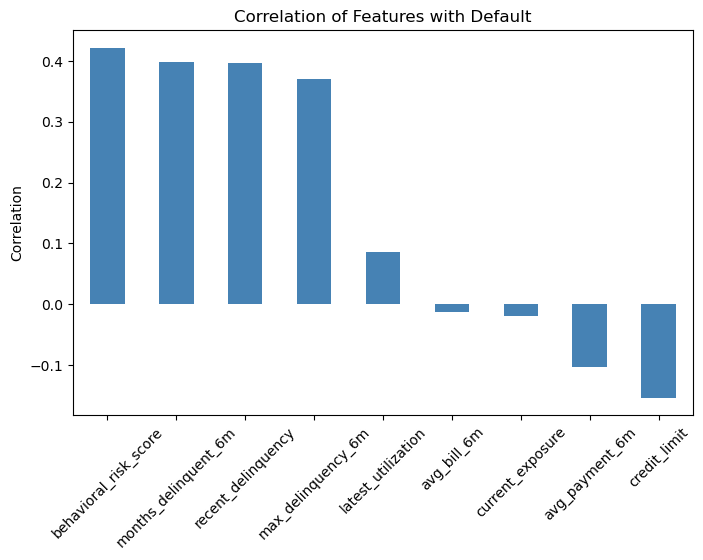

In [22]:
plt.figure(figsize=(8,5))

corr_target.drop("default_next_month").plot(kind="bar", color="steelblue")

plt.title("Correlation of Features with Default")
plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.show()